# Lab 8: Custom CNN Model for Corn Leaf Image Classification

**Student Name:** Yousaf Tahir  
**Registration Number:** 22JZELE0479  
**Course:** Machine Learning Lab  
**Supervisor:** Engr. Irshad Ullah  
**University:** UET Nowshera Campus  



## Learning Objectives
- Import TensorFlow/Keras layers, models, optimizers, and image preprocessing tools.
- Load images from train, validation, and test directories using ImageDataGenerator.
- Build and compile a custom CNN model for multi-class image classification.
- Train the CNN model and monitor validation performance using checkpoints.
- Evaluate the trained model using accuracy, confusion matrix, and classification report.

## Section 1: Library Import and Path Setup
This section imports Keras, plotting, NumPy, and evaluation libraries, then defines checkpoint and dataset paths.


# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

In [3]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [4]:
checkpoints = r'D:\Machine Learning\ML Lab\Lab 8\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [5]:
train_dir = r'D:\Machine Learning\ML Lab\Lab 8\Computer vision\sectionB\train'
validation_dir = r'D:\Machine Learning\ML Lab\Lab 8\Computer vision\sectionB\validation'
test_dir = r'D:\Machine Learning\ML Lab\Lab 8\Computer vision\sectionB\test'

## Section 2: CNN Architecture Design
The following cells create the CNN model using convolution, pooling, flattening, dense, and output layers.


In [6]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

c:\Users\Yousaf Tahir\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.RMSprop(learning_rate=1e-4),
    metrics=['accuracy']
)

In [9]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## Section 3: Data Generators and Model Training
This section loads image batches from folders, applies rescaling, sets checkpoints, and trains the CNN model.


In [10]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [12]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=2,
                    callbacks=callbacks)

Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6244 - loss: 0.8952
Epoch 1: val_loss improved from None to 0.63768, saving model to D:\Machine Learning\ML Lab\Lab 8\\E1-cp-0001-loss0.64.h5



Epoch 1: finished saving model to D:\Machine Learning\ML Lab\Lab 8\\E1-cp-0001-loss0.64.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.6244 - loss: 0.8952 - val_accuracy: 0.6706 - val_loss: 0.6377
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7506 - loss: 0.5553
Epoch 2: val_loss improved from 0.63768 to 0.49540, saving model to D:\Machine Learning\ML Lab\Lab 8\\E1-cp-0002-loss0.50.h5



Epoch 2: finished saving model to D:\Machine Learning\ML Lab\Lab 8\\E1-cp-0002-loss0.50.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.7506 - loss: 0.5553 - val_accuracy: 0.7698 - val_loss: 0.4954


In [13]:
model_history.history

{'accuracy': [0.6243749856948853, 0.7506250143051147],
 'loss': [0.8951534032821655, 0.5552866458892822],
 'val_accuracy': [0.670634925365448, 0.7698412537574768],
 'val_loss': [0.6376768350601196, 0.4953981637954712]}

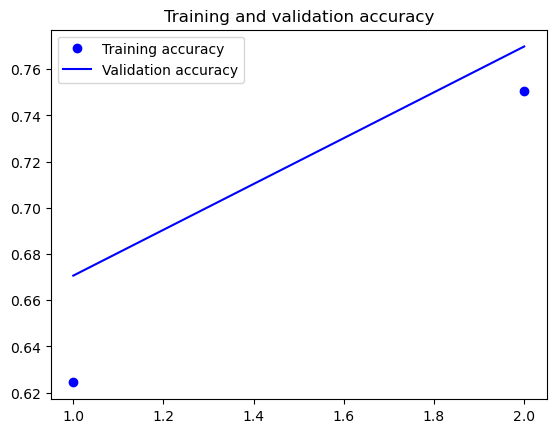

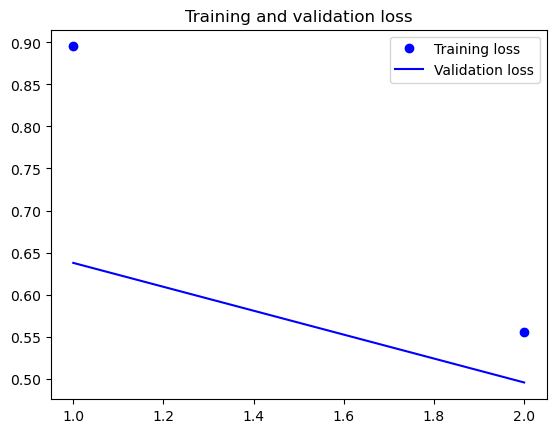

In [15]:
acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.savefig(r'D:\Machine Learning\ML Lab\Lab 8\model_Accuracy.png')

plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.savefig(r'D:\Machine Learning\ML Lab\Lab 8\model_Loss.png')

plt.show()

## Section 4: Model Evaluation and Visualization
The final cells evaluate model performance using plots, predictions, confusion matrix, and classification report.


In [16]:
model.save(r'D:\Machine Learning\ML Lab\Lab 8\\E1-cp-0002-loss0.50.h5')

Found 200 images belonging to 4 classes.


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 341ms/step


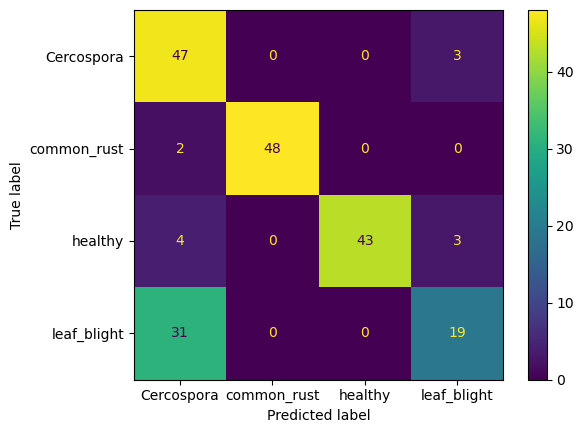

In [17]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'Z:\University\8th Semester\ML Lab\Lab 7,8\confusion_matrics.jpg')

In [18]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.56      0.94      0.70        50
 common_rust       1.00      0.96      0.98        50
     healthy       1.00      0.86      0.92        50
 leaf_blight       0.76      0.38      0.51        50

    accuracy                           0.79       200
   macro avg       0.83      0.78      0.78       200
weighted avg       0.83      0.79      0.78       200



## Final Conclusion
In this lab, a custom CNN was trained for corn leaf image classification using the prepared dataset. The model was evaluated using visual training curves and classification metrics.